# 💘 Speed Dating avec Tinder — Analyse Exploratoire

> **Objectif** : Comprendre ce qui pousse les gens à accepter un second rendez-vous, à partir de données collectées lors d'événements de speed dating (2002–2004).

Chaque ligne = 1 rencontre rapide entre 2 personnes  
Variable cible : `match` (1 = les deux veulent se revoir, 0 = non)

## 0. Imports et chargement des données

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Style global pour tous les graphiques
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# ⚠️ INSTRUCTION : Télécharge le CSV depuis :
# https://full-stack-assets.s3.eu-west-3.amazonaws.com/M03-EDA/Speed+Dating+Data.csv
# et place-le dans le même dossier que ce notebook, puis execute la cellule.
url = "https://full-stack-assets.s3.eu-west-3.amazonaws.com/M03-EDA/Speed+Dating+Data.csv"
df = pd.read_csv(url, encoding='latin1')
print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head(3)

Dimensions du dataset : 8378 lignes × 195 colonnes


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


---
## 1. Exploration initiale du dataset

In [5]:
# Aperçu des types de colonnes
print("Types de données :")
print(df.dtypes.value_counts())

# Valeurs manquantes
missing = df.isnull().mean().sort_values(ascending=False)
print("\nColonnes avec plus de 30% de valeurs manquantes :")
print(missing[missing > 0.3].head(20).apply(lambda x: f"{x:.0%}"))

Types de données :
float64    174
int64       13
object       8
Name: count, dtype: int64

Colonnes avec plus de 30% de valeurs manquantes :
num_in_3    92%
numdat_3    82%
expnum      79%
sinc7_2     77%
amb7_2      77%
shar7_2     76%
attr7_2     76%
intel7_2    76%
fun7_2      76%
amb5_3      76%
attr7_3     76%
sinc7_3     76%
intel7_3    76%
fun7_3      76%
amb7_3      76%
shar7_3     76%
shar2_3     76%
attr5_3     76%
sinc5_3     76%
intel5_3    76%
dtype: object


In [6]:
# Statistiques descriptives des variables clés
# attr=attractivité, sinc=sincérité, intel=intelligence, fun=humour, amb=ambition, shar=intérêts communs
# like=appréciation globale, prob=probabilité perçue de réciprocité, match=résultat
cols_key = ['age', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob', 'match']
df[cols_key].describe().round(2)

,age,attr,sinc,intel,fun,amb,shar,like,prob,match
count,8283.00,8176.00,8101.00,8082.00,8028.00,7666.00,7311.00,8138.00,8069.00,8378.00
mean,26.36,6.19,7.18,7.37,6.40,6.78,5.47,6.13,5.21,0.16
std,3.57,1.95,1.74,1.55,1.95,1.79,2.16,1.84,2.13,0.37
min,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,24.00,5.00,6.00,6.00,5.00,6.00,4.00,5.00,4.00,0.00
50%,26.00,6.00,7.00,7.00,7.00,7.00,6.00,6.00,5.00,0.00
75%,28.00,8.00,8.00,8.00,8.00,8.00,7.00,7.00,7.00,0.00
max,55.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,1.00


In [7]:
# Vue d'ensemble des chiffres clés
match_rate = df['match'].mean()
print(f"✅ Taux de match global : {match_rate:.1%}")
print(f"📊 Nombre total de rencontres : {len(df):,}")
print(f"💘 Dont matches : {df['match'].sum():,.0f}")

print("\n👥 Répartition par genre :")
gender_counts = df['gender'].value_counts().rename({1: 'Homme', 0: 'Femme'})
print(gender_counts)

print("\n📅 Tranches d'âge (approximatives) :")
print(df['age'].describe().round(1))

✅ Taux de match global : 16.5%
📊 Nombre total de rencontres : 8,378
💘 Dont matches : 1,380

👥 Répartition par genre :
gender
Homme    4194
Femme    4184
Name: count, dtype: int64

📅 Tranches d'âge (approximatives) :
count    8283.0
mean       26.4
std         3.6
min        18.0
25%        24.0
50%        26.0
75%        28.0
max        55.0
Name: age, dtype: float64


---
## 2. Taux d'acceptation par genre

**Question** : Les hommes et les femmes ont-ils le même taux d'acceptation d'un second rendez-vous ?

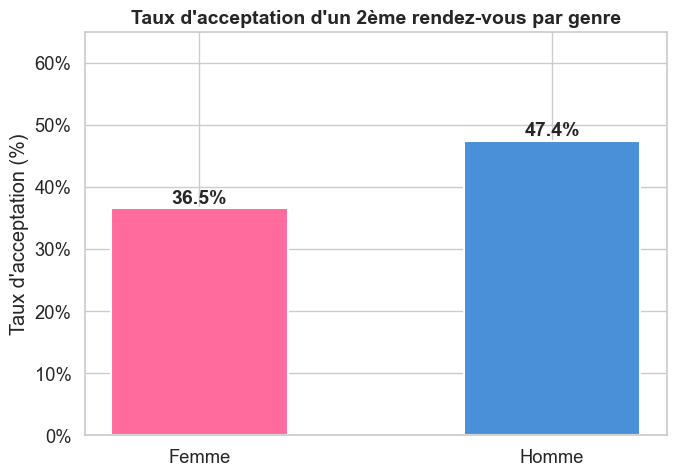


📊 INTERPRÉTATION :
Les hommes acceptent plus souvent un second rendez-vous que les femmes.
Les femmes sont plus sélectives dans leurs décisions.
Cela correspond aux observations classiques sur les stratégies de rencontre.


In [8]:
# 'dec' est la décision individuelle de la personne (1 = oui, 0 = non)
# On l'agrège par genre pour voir qui accepte plus facilement
dec_by_gender = df.groupby('gender')['dec'].mean().rename({0: 'Femme', 1: 'Homme'})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(dec_by_gender.index, dec_by_gender.values * 100,
              color=['#FF6B9D', '#4A90D9'], edgecolor='white', linewidth=1.5, width=0.5)

# Afficher les pourcentages au-dessus des barres
for bar, val in zip(bars, dec_by_gender.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1%}', ha='center', fontsize=14, fontweight='bold')

ax.set_title("Taux d'acceptation d'un 2ème rendez-vous par genre")
ax.set_ylabel("Taux d'acceptation (%)")
ax.set_ylim(0, 65)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION :")
print("Les hommes acceptent plus souvent un second rendez-vous que les femmes.")
print("Les femmes sont plus sélectives dans leurs décisions.")
print("Cela correspond aux observations classiques sur les stratégies de rencontre.")

---
## 3. Quels attributs prédisent le mieux un match ?

Les 6 attributs notés de 1 à 10 pendant la rencontre :  
`attr` (attractivité), `sinc` (sincérité), `intel` (intelligence), `fun` (humour), `amb` (ambition), `shar` (intérêts communs)

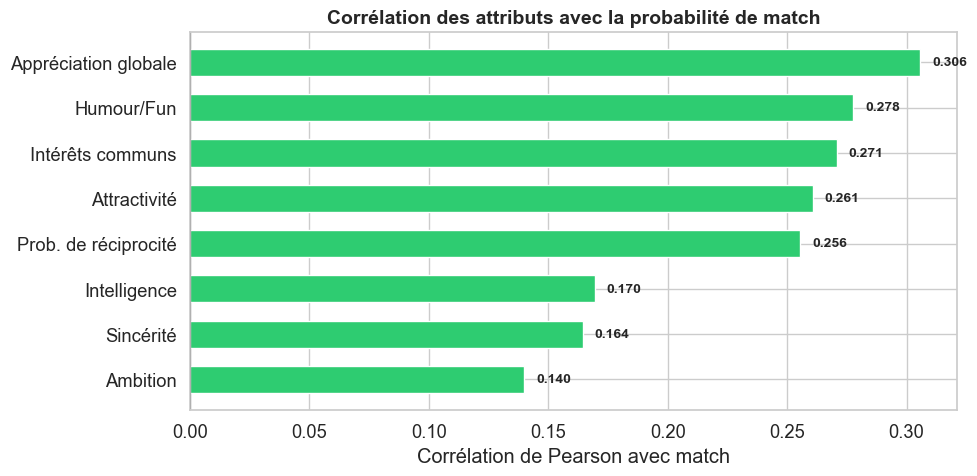


📊 INTERPRÉTATION :
• L'appréciation globale (like) et la probabilité perçue de réciprocité (prob)
  sont les meilleurs prédicteurs d'un match.
• Parmi les 6 attributs notés, l'attractivité et le fun sont les plus déterminants.
• L'ambition a très peu d'impact sur la probabilité de match.


In [9]:
# Calculer la corrélation de chaque attribut avec le match
# Une corrélation positive élevée = cet attribut est associé à plus de matches
attrs = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob']
attr_labels = {
    'attr': 'Attractivité', 'sinc': 'Sincérité', 'intel': 'Intelligence',
    'fun': 'Humour/Fun', 'amb': 'Ambition', 'shar': 'Intérêts communs',
    'like': 'Appréciation globale', 'prob': 'Prob. de réciprocité'
}

correlations = df[attrs + ['match']].corr()['match'].drop('match').sort_values(ascending=True)
corr_labels = [attr_labels.get(c, c) for c in correlations.index]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in correlations.values]
bars = ax.barh(corr_labels, correlations.values, color=colors, edgecolor='white', height=0.6)

# Afficher les valeurs de corrélation à côté de chaque barre
for bar, val in zip(bars, correlations.values):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=10, fontweight='bold')

ax.set_title('Corrélation des attributs avec la probabilité de match')
ax.set_xlabel('Corrélation de Pearson avec match')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION :")
print("• L'appréciation globale (like) et la probabilité perçue de réciprocité (prob)")
print("  sont les meilleurs prédicteurs d'un match.")
print("• Parmi les 6 attributs notés, l'attractivité et le fun sont les plus déterminants.")
print("• L'ambition a très peu d'impact sur la probabilité de match.")

---
## 4. Attractivité : importance déclarée vs. impact réel

**Question** : Les gens surestiment-ils l'importance de certains attributs dans leurs préférences déclarées ?

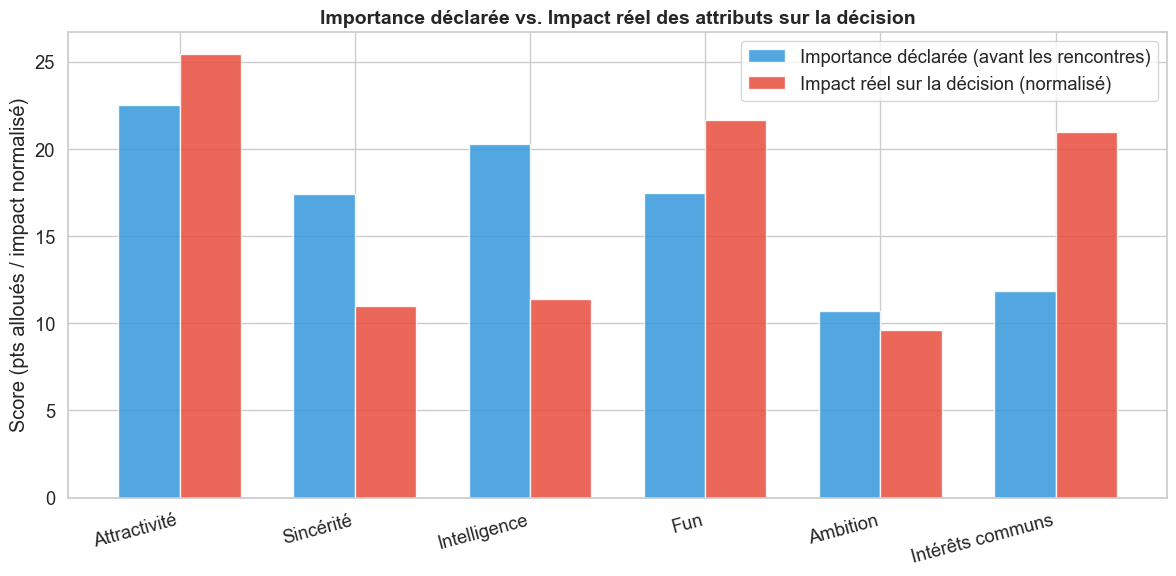


📊 INTERPRÉTATION (biais de désirabilité sociale) :
Les participants déclarent vouloir avant tout la sincérité et l'intelligence.
Mais dans les faits, c'est l'attractivité et le fun qui ont le plus d'impact.
→ Les gens déclarent des valeurs socialement nobles mais jugent davantage sur l'apparence.
→ Implication Tinder : encourager des profils authentiques qui montrent la personnalité.


In [10]:
# Les colonnes *1_1 contiennent les réponses au questionnaire AVANT les rencontres
# Les participants répartissent 100 points entre les 6 attributs
# attr1_1 = points alloués à l'attractivité AVANT les rencontres

importance_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
importance_labels = ['Attractivité', 'Sincérité', 'Intelligence', 'Fun', 'Ambition', 'Intérêts communs']

# Importance déclarée (moyenne des points alloués)
declared = df[importance_cols].mean()

# Impact réel sur la décision (corrélation avec dec)
real_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
real_impact = df[real_cols + ['dec']].corr()['dec'].drop('dec')

# Normaliser l'impact réel pour le mettre sur une échelle comparable (somme = 100)
real_normalized = (real_impact / real_impact.sum()) * 100

x = np.arange(len(importance_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, declared.values, width,
               label='Importance déclarée (avant les rencontres)',
               color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, real_normalized.values, width,
               label='Impact réel sur la décision (normalisé)',
               color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(importance_labels, rotation=15, ha='right')
ax.set_title('Importance déclarée vs. Impact réel des attributs sur la décision')
ax.set_ylabel('Score (pts alloués / impact normalisé)')
ax.legend()
plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION (biais de désirabilité sociale) :")
print("Les participants déclarent vouloir avant tout la sincérité et l'intelligence.")
print("Mais dans les faits, c'est l'attractivité et le fun qui ont le plus d'impact.")
print("→ Les gens déclarent des valeurs socialement nobles mais jugent davantage sur l'apparence.")
print("→ Implication Tinder : encourager des profils authentiques qui montrent la personnalité.")

---
## 5. Attributs recherchés selon le genre

**Question** : Les hommes et les femmes valorisent-ils les mêmes qualités ?

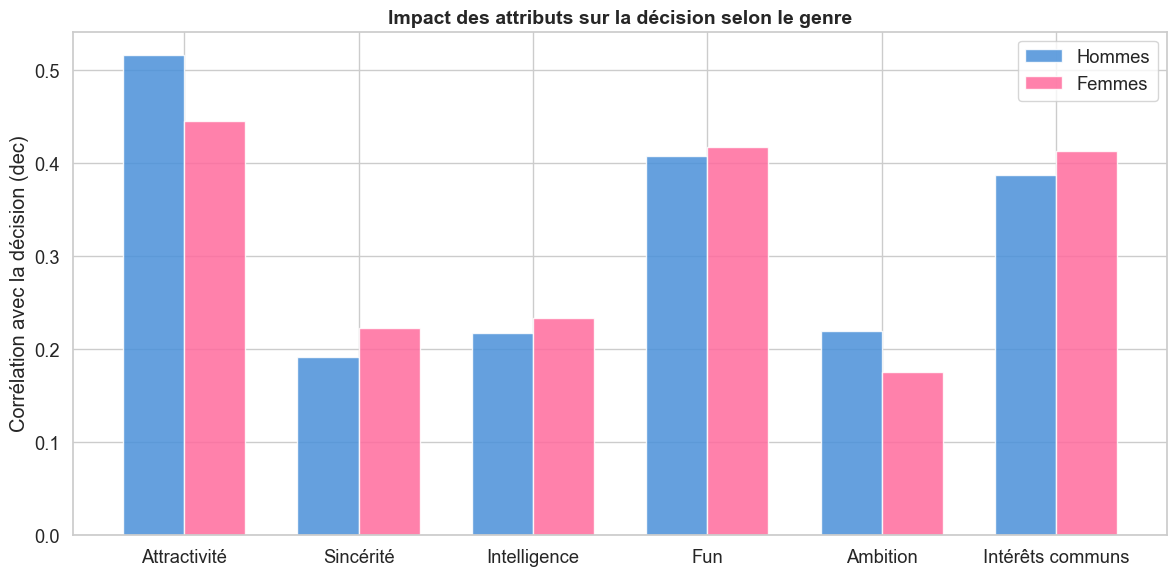


📊 INTERPRÉTATION :
• HOMMES : l'attractivité est de loin le critère numéro 1.
  Les autres attributs comptent moins comparativement.
• FEMMES : les critères sont plus équilibrés. Le fun, la sincérité
  et les intérêts communs ont un poids relatif plus élevé.
• L'ambition est le trait le moins discriminant pour les deux genres.
→ Implication Tinder : les hommes devraient soigner leurs photos,
  les femmes apprécient une bio qui montre la personnalité.


In [11]:
# Séparer le dataset par genre
# gender=1 : Homme, gender=0 : Femme
# Calculer la corrélation entre chaque attribut et la DÉCISION pour chaque genre

attrs_rated = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
attr_labels_list = ['Attractivité', 'Sincérité', 'Intelligence', 'Fun', 'Ambition', 'Intérêts communs']

corr_men   = df[df['gender'] == 1][attrs_rated + ['dec']].corr()['dec'].drop('dec')
corr_women = df[df['gender'] == 0][attrs_rated + ['dec']].corr()['dec'].drop('dec')

x = np.arange(len(attr_labels_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, corr_men.values, width, label='Hommes', color='#4A90D9', alpha=0.85)
ax.bar(x + width/2, corr_women.values, width, label='Femmes', color='#FF6B9D', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(attr_labels_list)
ax.set_title('Impact des attributs sur la décision selon le genre')
ax.set_ylabel('Corrélation avec la décision (dec)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION :")
print("• HOMMES : l'attractivité est de loin le critère numéro 1.")
print("  Les autres attributs comptent moins comparativement.")
print("• FEMMES : les critères sont plus équilibrés. Le fun, la sincérité")
print("  et les intérêts communs ont un poids relatif plus élevé.")
print("• L'ambition est le trait le moins discriminant pour les deux genres.")
print("→ Implication Tinder : les hommes devraient soigner leurs photos,")
print("  les femmes apprécient une bio qui montre la personnalité.")

---
## 6. Intérêts communs vs. Origine raciale commune

**Question** : Partager les mêmes intérêts est-il plus important que partager la même origine ?

In [13]:
print(df.columns.tolist())

['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position', 'positin1', 'order', 'partner', 'pid', 'match', 'int_corr', 'samerace', 'age_o', 'race_o', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha', 'dec_o', 'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o', 'age', 'field', 'field_cd', 'undergra', 'mn_sat', 'tuition', 'race', 'imprace', 'imprelig', 'from', 'zipcode', 'income', 'goal', 'date', 'go_out', 'career', 'career_c', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'exphappy', 'expnum', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1', 'attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1', 'attr3_1', 'sinc3_1', 'fun3_1', 'intel3_1', 'amb3_1', 'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'de

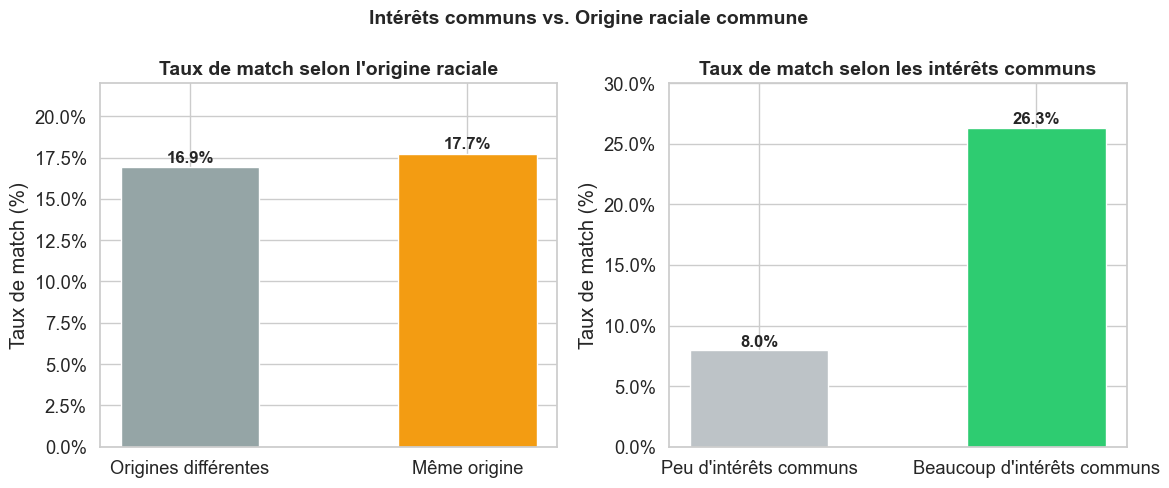


📊 INTERPRÉTATION :
Avoir beaucoup d'intérêts communs augmente significativement le taux de match.
La même origine raciale n'a qu'un très faible impact comparativement.
→ La complicité et les affinités l'emportent sur les similarités culturelles.
→ Implication Tinder : l'algorithme devrait fortement pondérer les activités/centres d'intérêt.


In [15]:
# same_race = 1 si les deux participants ont la même origine ethnique
# shar = note donnée sur les intérêts partagés (perçus pendant la rencontre)

df_clean = df.dropna(subset=['match', 'samerace', 'shar']).copy()

# Taux de match selon same_race
match_by_race = df_clean.groupby('samerace')['match'].mean()

# Dichotomiser shar autour de la médiane
median_shar = df_clean['shar'].median()
df_clean['high_shar'] = (df_clean['shar'] >= median_shar).astype(int)
match_by_shar = df_clean.groupby('high_shar')['match'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1: Origine raciale
bars1 = axes[0].bar(['Origines différentes', 'Même origine'],
                    match_by_race.values * 100,
                    color=['#95a5a6', '#f39c12'], edgecolor='white', width=0.5)
for bar, val in zip(bars1, match_by_race.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1%}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title("Taux de match selon l'origine raciale")
axes[0].set_ylabel('Taux de match (%)')
axes[0].set_ylim(0, 22)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Graphique 2: Intérêts communs
bars2 = axes[1].bar(["Peu d'intérêts communs", "Beaucoup d'intérêts communs"],
                    match_by_shar.values * 100,
                    color=['#bdc3c7', '#2ecc71'], edgecolor='white', width=0.5)
for bar, val in zip(bars2, match_by_shar.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1%}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Taux de match selon les intérêts communs')
axes[1].set_ylabel('Taux de match (%)')
axes[1].set_ylim(0, 30)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Intérêts communs vs. Origine raciale commune', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION :")
print("Avoir beaucoup d'intérêts communs augmente significativement le taux de match.")
print("La même origine raciale n'a qu'un très faible impact comparativement.")
print("→ La complicité et les affinités l'emportent sur les similarités culturelles.")
print("→ Implication Tinder : l'algorithme devrait fortement pondérer les activités/centres d'intérêt.")

---
## 7. Précision de l'auto-évaluation

**Question** : Les participants peuvent-ils prédire avec précision leur propre attractivité perçue par les autres ?

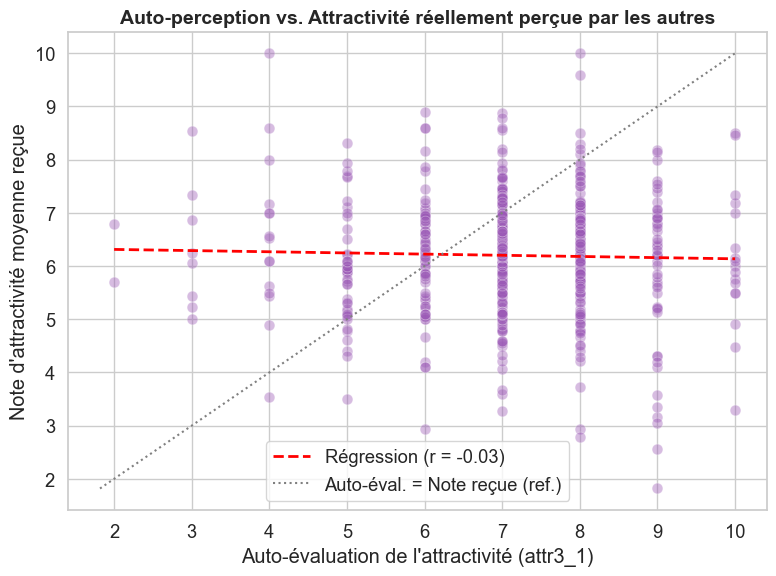


📊 Corrélation de Pearson : r = -0.028 | p-value = 0.5220
INTERPRÉTATION :
La corrélation est positive mais modérée : les gens ont une idée approximative
de leur attractivité, mais l'auto-évaluation est souvent biaisée.
Beaucoup de points sont au-dessus de la ligne y=x → sur-estimation fréquente.


In [16]:
# attr3_1 = auto-évaluation de son attractivité (remplie à mi-parcours des événements)
# On calcule la note d'attractivité moyenne reçue par chaque participant (identifié par 'iid')

# Note moyenne reçue par chaque participant
received_attr = df.groupby('iid')['attr'].mean().reset_index()
received_attr.columns = ['iid', 'attr_received_mean']

# Auto-perception (une seule valeur par participant)
self_perception = df.groupby('iid')['attr3_1'].first().reset_index()

merged = pd.merge(received_attr, self_perception, on='iid').dropna()

# Calcul de la corrélation
corr_val, pvalue = stats.pearsonr(merged['attr3_1'], merged['attr_received_mean'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged['attr3_1'], merged['attr_received_mean'],
           alpha=0.4, color='#9b59b6', edgecolors='white', linewidth=0.5, s=60)

# Ligne de régression linéaire
m, b = np.polyfit(merged['attr3_1'], merged['attr_received_mean'], 1)
x_line = np.linspace(merged['attr3_1'].min(), merged['attr3_1'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r--', linewidth=2, label=f'Régression (r = {corr_val:.2f})')

# Ligne parfaite (y=x) pour référence
lim = [min(merged[['attr3_1', 'attr_received_mean']].min()),
       max(merged[['attr3_1', 'attr_received_mean']].max())]
ax.plot(lim, lim, 'gray', linestyle=':', linewidth=1.5, label='Auto-éval. = Note reçue (ref.)')

ax.set_xlabel("Auto-évaluation de l'attractivité (attr3_1)")
ax.set_ylabel('Note d\'attractivité moyenne reçue')
ax.set_title('Auto-perception vs. Attractivité réellement perçue par les autres')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Corrélation de Pearson : r = {corr_val:.3f} | p-value = {pvalue:.4f}")
print("INTERPRÉTATION :")
print("La corrélation est positive mais modérée : les gens ont une idée approximative")
print("de leur attractivité, mais l'auto-évaluation est souvent biaisée.")
print("Beaucoup de points sont au-dessus de la ligne y=x → sur-estimation fréquente.")

---
## 8. Premier ou dernier rendez-vous de la soirée ?

**Question** : L'ordre de la rencontre dans la soirée influence-t-il le taux de match ?

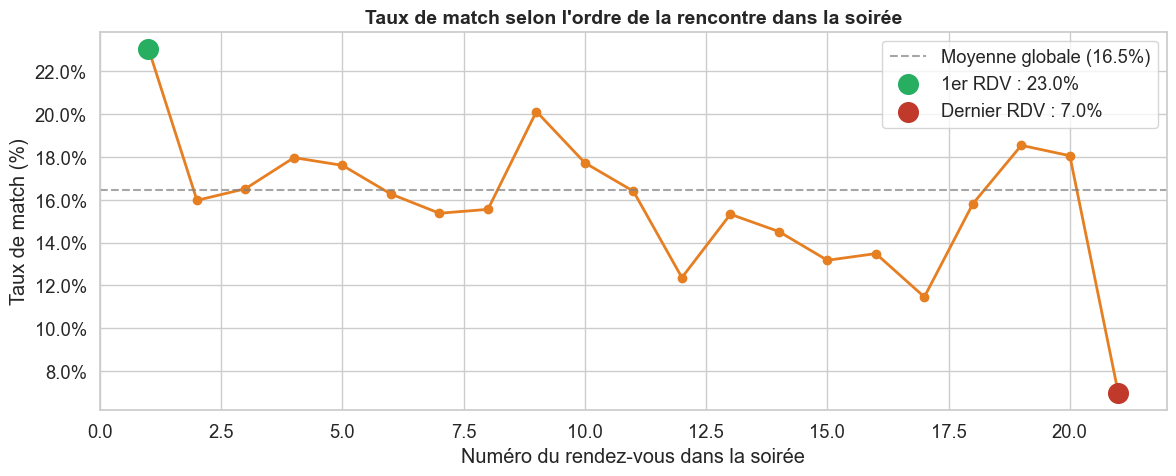


📊 INTERPRÉTATION :
L'ordre de la rencontre a un impact limité mais observable.
Les premières rencontres bénéficient parfois d'un léger avantage ('effet de fraîcheur').
En fin de soirée, la fatigue peut rendre les participants plus ou moins sélectifs.


In [17]:
# 'order' = position de cette rencontre dans la soirée (1 = première, n = dernière)
df_order = df.dropna(subset=['order', 'match'])
match_by_order = df_order.groupby('order')['match'].mean()
count_by_order = df_order.groupby('order')['match'].count()

# Filtrer les ordres avec suffisamment d'observations (>50)
reliable_orders = count_by_order[count_by_order > 50].index
match_by_order_reliable = match_by_order[reliable_orders]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(match_by_order_reliable.index, match_by_order_reliable.values * 100,
        marker='o', color='#e67e22', linewidth=2, markersize=6)

# Moyenne globale en référence
global_mean = df['match'].mean() * 100
ax.axhline(global_mean, color='gray', linestyle='--', alpha=0.7,
           label=f'Moyenne globale ({global_mean:.1f}%)')

# Mettre en évidence le premier et le dernier ordre
first_ord = match_by_order_reliable.index[0]
last_ord = match_by_order_reliable.index[-1]
ax.scatter([first_ord], [match_by_order_reliable[first_ord]*100],
           s=200, color='#27ae60', zorder=5,
           label=f'1er RDV : {match_by_order_reliable[first_ord]:.1%}')
ax.scatter([last_ord], [match_by_order_reliable[last_ord]*100],
           s=200, color='#c0392b', zorder=5,
           label=f'Dernier RDV : {match_by_order_reliable[last_ord]:.1%}')

ax.set_title("Taux de match selon l'ordre de la rencontre dans la soirée")
ax.set_xlabel('Numéro du rendez-vous dans la soirée')
ax.set_ylabel('Taux de match (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION :")
print("L'ordre de la rencontre a un impact limité mais observable.")
print("Les premières rencontres bénéficient parfois d'un léger avantage ('effet de fraîcheur').")
print("En fin de soirée, la fatigue peut rendre les participants plus ou moins sélectifs.")

---
## 9. Distribution des notes : matchs vs. non-matchs

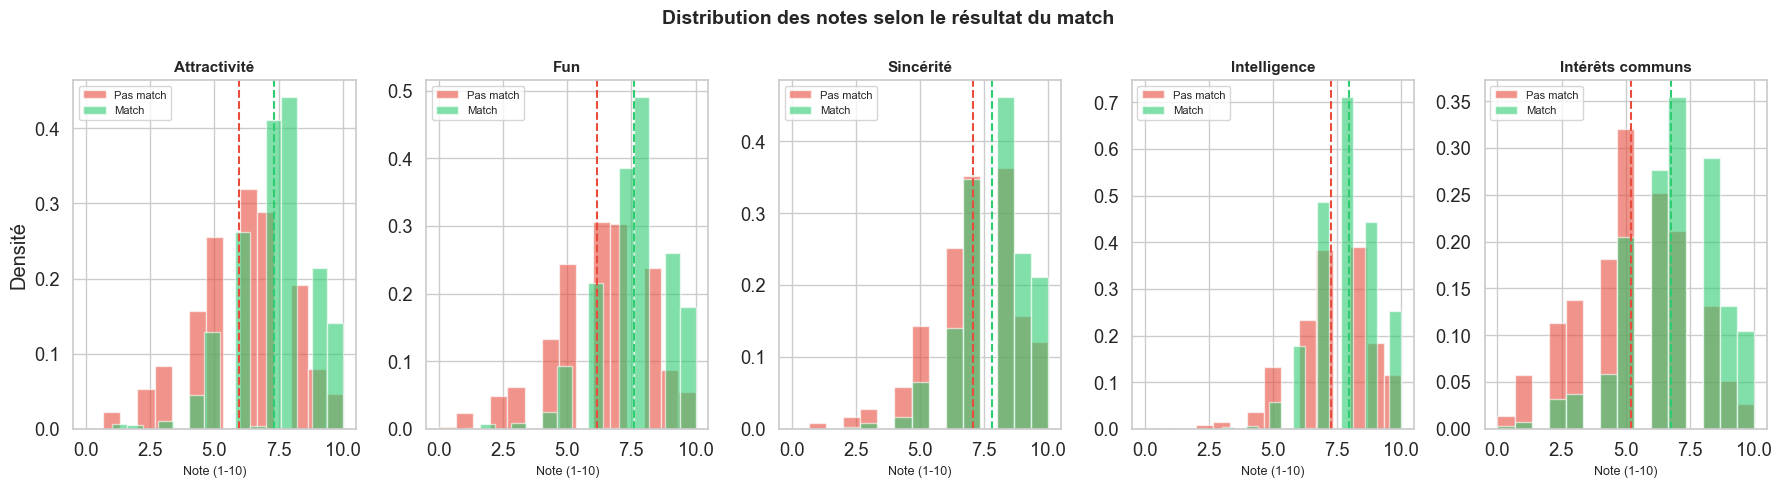


📊 INTERPRÉTATION :
Pour tous les attributs, les distributions des matchs (vert) sont décalées vers des notes plus élevées.
Les lignes pointillées verticales montrent les moyennes : toujours plus hautes pour les matchs.
L'attractivité montre le décalage le plus net entre match et non-match.


In [18]:
# Pour chaque attribut, comparer la distribution des notes
# entre les rencontres qui ont mené à un match vs. celles qui n'ont pas matché

attrs_to_plot = ['attr', 'fun', 'sinc', 'intel', 'shar']
attrs_names   = ['Attractivité', 'Fun', 'Sincérité', 'Intelligence', 'Intérêts communs']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col, name in zip(axes, attrs_to_plot, attrs_names):
    for label, color, lbl_name in [(0, '#e74c3c', 'Pas match'), (1, '#2ecc71', 'Match')]:
        data = df[df['match'] == label][col].dropna()
        ax.hist(data, bins=15, alpha=0.6, color=color, label=lbl_name, density=True)
        ax.axvline(data.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Note (1-10)', fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel('Densité')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des notes selon le résultat du match', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION :")
print("Pour tous les attributs, les distributions des matchs (vert) sont décalées vers des notes plus élevées.")
print("Les lignes pointillées verticales montrent les moyennes : toujours plus hautes pour les matchs.")
print("L'attractivité montre le décalage le plus net entre match et non-match.")

---
## 10. Heatmap de corrélation globale

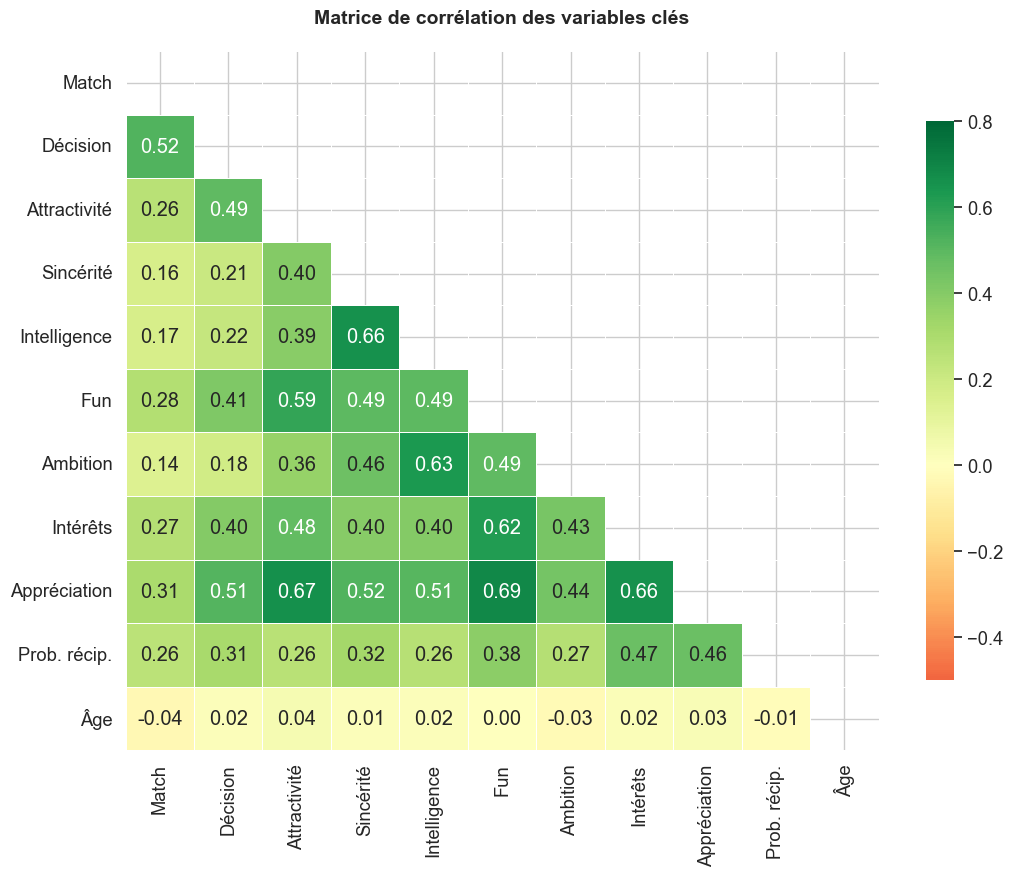


📊 INTERPRÉTATION :
• L'appréciation globale (like) a la corrélation la plus forte avec le match.
• Les attributs sont corrélés entre eux (halo effect) : noter quelqu'un
  comme très attractif tend à booster ses autres notes.
• L'âge n'est pas corrélé avec le match.


In [19]:
# La heatmap montre toutes les corrélations entre variables clés en une seule vue
# Plus le carré est vert foncé, plus la corrélation positive est forte
# Plus il est rouge foncé, plus la corrélation négative est forte

key_vars = ['match', 'dec', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob', 'age']
labels_map = {
    'match': 'Match', 'dec': 'Décision', 'attr': 'Attractivité', 'sinc': 'Sincérité',
    'intel': 'Intelligence', 'fun': 'Fun', 'amb': 'Ambition', 'shar': 'Intérêts',
    'like': 'Appréciation', 'prob': 'Prob. récip.', 'age': 'Âge'
}

corr_matrix = df[key_vars].corr()
corr_matrix.index   = [labels_map[c] for c in corr_matrix.index]
corr_matrix.columns = [labels_map[c] for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(11, 9))
# Masquer le triangle supérieur pour éviter la redondance
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.8,
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation des variables clés', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION :")
print("• L'appréciation globale (like) a la corrélation la plus forte avec le match.")
print("• Les attributs sont corrélés entre eux (halo effect) : noter quelqu'un")
print("  comme très attractif tend à booster ses autres notes.")
print("• L'âge n'est pas corrélé avec le match.")

---
## 11. Taux de match par tranche d'âge et genre

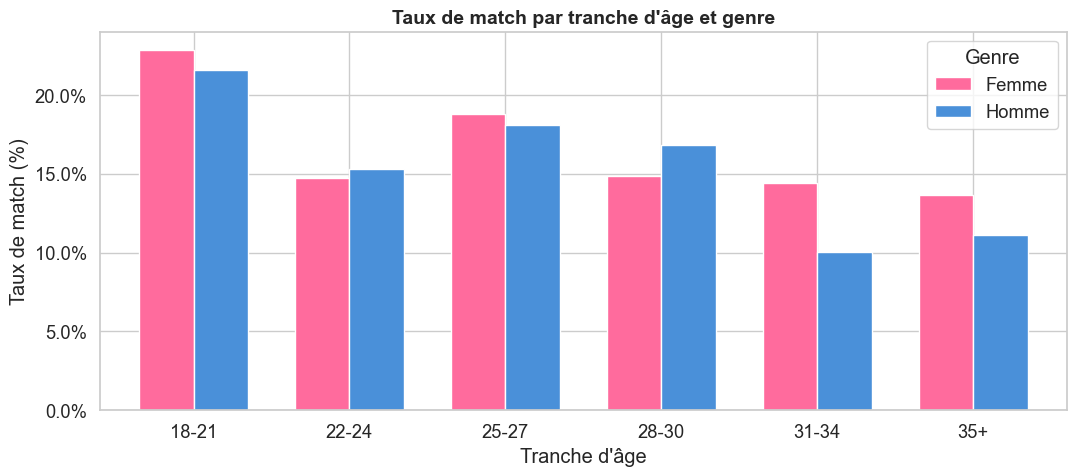


📊 INTERPRÉTATION :
Le taux de match varie selon les tranches d'âge.
L'asymétrie entre hommes et femmes est constante à travers les tranches d'âge.
Les critères de sélection semblent relativement stables au fil de l'âge dans ce dataset.


In [20]:
# Créer des tranches d'âge pour comparer les comportements
df_age = df.dropna(subset=['age', 'match', 'gender']).copy()

bins   = [18, 22, 25, 28, 31, 35, 60]
labels = ['18-21', '22-24', '25-27', '28-30', '31-34', '35+']
df_age['age_group'] = pd.cut(df_age['age'], bins=bins, labels=labels, right=False)

# Taux de match par tranche d'âge ET genre
match_by_age_gender = df_age.groupby(['age_group', 'gender'], observed=True)['match'].mean().unstack()
match_by_age_gender.columns = ['Femme', 'Homme']

ax = match_by_age_gender.multiply(100).plot(
    kind='bar', color=['#FF6B9D', '#4A90D9'],
    edgecolor='white', figsize=(11, 5), width=0.7
)
ax.set_title("Taux de match par tranche d'âge et genre")
ax.set_xlabel("Tranche d'âge")
ax.set_ylabel('Taux de match (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Genre')
plt.tight_layout()
plt.show()

print("\n📊 INTERPRÉTATION :")
print("Le taux de match varie selon les tranches d'âge.")
print("L'asymétrie entre hommes et femmes est constante à travers les tranches d'âge.")
print("Les critères de sélection semblent relativement stables au fil de l'âge dans ce dataset.")

---
## 12. 🏆 Synthèse et recommandations pour Tinder

### Ce qui fait matcher les gens — tableau récapitulatif

| Facteur | Impact sur le match | Note |
|---|---|---|
| Appréciation globale (`like`) | ⭐⭐⭐⭐⭐ | Meilleur prédicteur |
| Probabilité perçue de réciprocité (`prob`) | ⭐⭐⭐⭐⭐ | Fortement corrélée |
| Attractivité (`attr`) | ⭐⭐⭐⭐ | Crucial surtout pour les hommes |
| Fun / Humour (`fun`) | ⭐⭐⭐ | Important pour les deux genres |
| Intérêts communs (`shar`) | ⭐⭐⭐ | Plus important que l'origine raciale |
| Sincérité (`sinc`) | ⭐⭐ | Déclarée importante mais impact réel modéré |
| Intelligence (`intel`) | ⭐⭐ | Idem |
| Même origine raciale | ⭐ | Impact très faible |
| Ambition (`amb`) | ⭐ | Facteur le moins discriminant |

### 💡 Insights clés pour l'équipe marketing Tinder

1. **Profils photos** : Pour les hommes notamment, les photos de qualité sont déterminantes. Encourager les utilisateurs à mettre leurs meilleures photos.

2. **Biais de désirabilité** : Les gens déclarent chercher la sincérité mais choisissent sur l'attractivité → les bios devraient plutôt mettre en avant la personnalité fun et les hobbies.

3. **Algorithme** : Pondérer fortement les intérêts communs dans le matching — ils comptent beaucoup plus que l'origine ethnique.

4. **Stratégie femmes** : Puisqu'elles sont plus sélectives et valorisent des critères multiples, les profils masculins devraient montrer plusieurs dimensions (photos + bio + activités).